# Simple Biopol LCA - with CITA numbers
Simple LCA for CITA's biopolymer panel. Includes the following processes: 
- 3D printing the panel 
- Pea protein binder
- Hemp dust filler
- Sea grass filler 

# Brightway project setup 

- A bw2 environment, project and database loaded with an ecoinvent copy need to be available in a separate local folder to be used by LcPy to derive the unit impacts of the sub-processes.
- be sure to use conda env `bw2`
- script was copied from [bw2 tutorial](https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html#)

In [1]:
import bw2io as bi
import bw2data as bd
import bw2calc as bc
import pandas as pd 

In [2]:
print(list(bd.projects)) #the prefix "bd" indicates that "projects" is a method of the bw2data package
bd.projects.set_current('biopol_lca') # activates a project, or creates it first if it doesn't exist yet
# bd.projects.migrate_project_25() 
print(list(bd.databases)) # check if there are databases in the project, and how they are named. 

[Project: default, Project: RAW_Reblakk, Project: Reblakk_2ndTry, Project: OpenLCA_Conversion, Project: RAW_timber_structure, Project: RAW_timber_structure_apos, Project: biopol_lca, Project: dummy_project, Project: biopol_lca_backup_ecoinvent_v391]
['lca_database_3DPrintedBiopol', 'biosphere-3.12', 'ecoinvent-3.12-cutoff']


In [3]:
bi.utils.DEFAULT_REQUEST_TIMEOUT = 600  # 600 seconds = 10 minutes

if 'ecoinvent-3.12-cutoff' in bd.databases:
    print('ecoinvent 3.12 is already present in the project')
else:
    bi.import_ecoinvent_release(
        version='3.12',
        system_model='cutoff', # can be cutoff / apos / consequential / EN15804
        username='LUCML',
        password='ecoV3JG62,0'
    )

ecoinvent 3.12 is already present in the project


# Add activities in activity-browser
The main processes are being added using the GUI activity-browser. See [MURAL board](https://app.mural.co/t/phd8054/m/phd8054/1756974417787/814130911a62286de97df9a05934b4ede2e1108f) for progress

# Calculate flow amounts
Calculate technosphere input flows based on assumptions, explicitly shown below in Python code

In [4]:
[node for node in bd.Database('lca_database_3DPrintedBiopol')]

['Drying with dehumidifying chamber' (kilogram, RER, None),
 'pea protein binder production' (kilogram, GLO, None),
 'seagrass filler production' (kilogram, GLO, None),
 'centrifugation' (kilogram, GLO, None),
 '3D printing' (kilogram, RER, None),
 'aqueous mixing' (kilogram, GLO, None),
 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None),
 'membrane filtration' (kilogram, GLO, None),
 'hemp dust filler production' (kilogram, GLO, None),
 'milling' (kilogram, GLO, None)]

## Drying

In [28]:
'''
Parameters for drying process calculations
- local climate conditions (temperature, relative humidity, atmospheric pressure)
- drying chamber conditions (volume, air infiltration rate, drying time, temperature, relative humidity)
- material drying conditions (number and dimensions of panels, water content, target evaporation percentage)
'''

# local climate conditions 
climate_temperature = 20 # °C
climate_relative_humidity = 0.85 # 50% relative humidity
climate_atmospheric_pressure = 101325 # Pa (sea level standard atmospheric pressure)

# drying chamber conditions
chamber_temperature = 20 
chamber_relative_humidity = 0.2 
drying_chamber_volume = 10
air_infiltration_per_hour = 1 # value for average building. Can be as low as 0.1 for well-sealed buildings
drying_time = 2 * 7 * 24 # hours (2 weeks)

# material drying conditions 
n_panels = 100 
liters_per_panel = 0.5 * 0.5 * 0.05 * 1000
liters_material = n_panels * liters_per_panel
g_water_per_liter_material = 682 # source: Carl for xantham gum 
evaporation_target = 0.75 # 70-80% of water needs to be evaporated 

# COP (coefficient of performance) for heating, cooling, and dehumidification 
# the higher the value, the more efficient the system 
cop_heating = 3 # typical value for electric heat pump
cop_cooling = 3 # typical value for electric heat pump
cop_dehumidification = 2 # typical value for electric dehumidifier

''' 
Calculations for energy required for drying
- calculate mass of water in the air to be removed (based on absolute humidity difference between outdoors and chamber, and volume of air to be processed)
- calculate mass of water in the wet material to be removed (based on water content of the material and target evaporation percentage)
- calculate energy required for drying (based on enthalpy of vaporization of water at the chamber temperature, and mass
'''

# get absolute humidity and dry air density
import psychrolib
psychrolib.SetUnitSystem(psychrolib.SI) # use SI units
absolute_humidity_outdoors = psychrolib.GetHumRatioFromRelHum(climate_temperature, climate_relative_humidity, climate_atmospheric_pressure) 
absoloute_humidity_chamber = psychrolib.GetHumRatioFromRelHum(chamber_temperature, chamber_relative_humidity, climate_atmospheric_pressure)
air_density = 1.2

# calculate mass of water in the air to be removed 
m3_air = drying_chamber_volume * air_infiltration_per_hour * drying_time # m3
kg_water_to_remove_from_air = (absolute_humidity_outdoors - absoloute_humidity_chamber) * m3_air * air_density # kg

# calculate mass of water in wet material
kg_water_in_wet_material = g_water_per_liter_material * liters_material / 1000 # convert g to kg
kg_water_to_remove_from_material = kg_water_in_wet_material * evaporation_target # kg of water to be removed from the material

# calculate energy required for drying 
enthalpy_of_vaporization = 2501 - 2.37 * chamber_temperature # standard rule-of-thumb formula for enthalpy of vaporization of water at different temperatures (kJ/kg)
kwh_energy_required_for_air = kg_water_to_remove_from_air * enthalpy_of_vaporization / 3600 / cop_dehumidification # convert kJ to kWh
kwh_energy_required_for_material = kg_water_to_remove_from_material * enthalpy_of_vaporization / 3600 / cop_dehumidification # convert kJ to kWh
kwh_energy_required_total = kwh_energy_required_for_air + kwh_energy_required_for_material
print("Dehumidification calculations:")
print(f"Energy required for drying air (kWh): {kwh_energy_required_for_air:.2f} ({kwh_energy_required_for_air / kwh_energy_required_total * 100:.1f}%)")
print(f"Energy required for drying material (kWh): {kwh_energy_required_for_material:.2f} ({kwh_energy_required_for_material / kwh_energy_required_total * 100:.1f}%)")
print(f"Energy required for drying (kWh): {kwh_energy_required_total:.2f}\n")

'''
Reference values for energy required for drying (source: Carl)
'''
# energy required for drying based on Carl's info: 4 machines, 255W per machine, 2 weeks of drying time
n_machines = 4 
w_per_machine = 255 
total_energy_kWh = n_machines * w_per_machine * drying_time / 1000
print(f"Reference energy required for drying (kWh): {total_energy_kWh:.2f}\n")

''' 
Calculate energy required for temperature control 
'''
kg_air = m3_air * air_density # kg of air to be processed
specific_heat_air = 1.005 # kJ/kg*K
temperature_difference = chamber_temperature - climate_temperature # K
kwh_energy_required_for_temperature_control = kg_air * specific_heat_air * temperature_difference / 3600 # convert kJ to kWh
if kwh_energy_required_for_temperature_control == 0:
    kwh_energy_required_for_temperature_control = 0 
elif kwh_energy_required_for_temperature_control < 0:
    kwh_energy_required_for_temperature_control = abs(kwh_energy_required_for_temperature_control) / cop_cooling # cooling is required, adjust for COP
else: 
    kwh_energy_required_for_temperature_control = kwh_energy_required_for_temperature_control / cop_heating # heating is required, adjust for COP
print("Temperature control calculations:")
print(f"Energy required for temperature control (kWh): {kwh_energy_required_for_temperature_control:.2f}\n")



Dehumidification calculations:
Energy required for drying air (kWh): 13.14 (5.7%)
Energy required for drying material (kWh): 217.88 (94.3%)
Energy required for drying (kWh): 231.02

Reference energy required for drying (kWh): 342.72

Temperature control calculations:
Energy required for temperature control (kWh): 0.00



In [5]:
# AMOUNTS FOR DRYING PROCESS — first-principles approach
# Energy consumption accounts for outdoor climate (temperature + humidity).
# All flows are per kg of dry output, independent of product geometry.

import math

# ── Climate inputs (set these per project location and season) ────────────────
T_outdoor_C  = 15.0   # outdoor temperature (°C)  — e.g. September in Denmark
RH_outdoor   = 0.8   # outdoor relative humidity  — e.g. 0.80 = 80%

# ── Chamber target conditions ─────────────────────────────────────────────────
T_indoor_C   = 20.0   # target chamber temperature (°C)
RH_indoor    = 0.20   # target chamber relative humidity

# ── Chamber physical parameters (educated guesses — flag for sensitivity) ─────
chamber_volume_m3 = 10.0   # m³ of air volume (estimated for a 3×2×2m room)
ACH               = 5    # air changes per hour (moderately well-sealed room)
air_density       = 1.2    # kg/m³ (standard air density at ~20°C)

# ── Material composition (from recipe) ───────────────────────────────────────
density_total_g_per_L  = 850   # g/L; midpoint of 800–900 g/L print density range
density_water_g_per_L  = 682   # g/L; water content from biopol recipe

water_fraction_wet = density_water_g_per_L / density_total_g_per_L

# ── Drying target ─────────────────────────────────────────────────────────────
evap_fraction = 0.75   # fraction of water content that must evaporate (midpoint of 70–80%)

water_evap_per_kg_wet     = water_fraction_wet * evap_fraction
kg_dry_per_kg_wet         = 1 - water_evap_per_kg_wet
kg_wetMaterial_perKg_dry  = 1 / kg_dry_per_kg_wet

# ── Chamber throughput (calibrated from 100-panel reference geometry) ─────────
n_panels_reference     = 100
panel_volume_L         = 0.50 * 0.50 * 0.05 * 1000   # 12.5 L per panel
kg_wet_per_chamber     = n_panels_reference * panel_volume_L * (density_total_g_per_L / 1000)
kg_dry_per_chamber     = kg_wet_per_chamber * kg_dry_per_kg_wet

hrs_drying = 2 * 7 * 24   # 2 weeks — fixed, chamber is always kept at target conditions

print(f'Wet material per chamber cycle:  {kg_wet_per_chamber:.1f} kg')
print(f'Dry output per chamber cycle:    {kg_dry_per_chamber:.1f} kg')
print(f'Drying time:                     {hrs_drying} hrs ({hrs_drying/(7*24):.0f} weeks)')

# ── Helper functions ──────────────────────────────────────────────────────────
def saturation_vapour_pressure_kPa(T_C):
    """How much water vapour air can hold at temperature T (Magnus equation)."""
    return 0.6108 * math.exp((17.27 * T_C) / (T_C + 237.3))

def absolute_humidity_kg_per_kg(T_C, RH):
    """Actual water content of air: kg of water per kg of dry air."""
    p_sat = saturation_vapour_pressure_kPa(T_C)
    p_w   = RH * p_sat
    return 0.622 * p_w / (101.325 - p_w)

# ── How much outdoor air enters the chamber per hour ─────────────────────────
# ACH (air changes per hour) tells us what fraction of the chamber volume
# is replaced by outdoor air each hour.
mass_flow_kg_per_hr = ACH * chamber_volume_m3 * air_density   # kg of air per hour

print(f'\nOutdoor air infiltrating the chamber: {mass_flow_kg_per_hr:.2f} kg/hr')

# ── Energy to control temperature ────────────────────────────────────────────
# Each kg of incoming outdoor air needs to be heated or cooled to 20°C.
# cp_air = 1.006 kJ per kg of air per °C of temperature change.
cp_air   = 1.006    # kJ/(kg·°C)
delta_T  = T_indoor_C - T_outdoor_C   # positive = need to heat, negative = need to cool

power_temperature_kW = mass_flow_kg_per_hr * cp_air * abs(delta_T) / 3600
# /3600 converts kJ/hr to kW

print(f'\nTemperature control:')
print(f'  Outdoor → indoor temperature difference: {delta_T:+.1f}°C')
print(f'  Power needed: {power_temperature_kW*1000:.1f} W')

# ── Energy to control humidity ────────────────────────────────────────────────
# Two sources of moisture need to be removed from the chamber air:
#   (1) moisture carried in by infiltrating outdoor air
#   (2) moisture evaporating off the drying material
# The dehumidifier handles both — it just sees total moisture in the room air.
#
# Removing water from air costs energy: ~2501 kJ per kg of water removed
# (this is the energy needed to condense water vapour back into liquid).
energy_per_kg_water_removed_kJ = 2501   # kJ/kg water

# Source 1: moisture from infiltrating outdoor air
W_outdoor = absolute_humidity_kg_per_kg(T_outdoor_C, RH_outdoor)
W_indoor  = absolute_humidity_kg_per_kg(T_indoor_C,  RH_indoor)
delta_W   = max(W_outdoor - W_indoor, 0)   # if outdoor air is already drier, no load

moisture_infiltration_kg_per_hr = mass_flow_kg_per_hr * delta_W
power_humidity_infiltration_kW  = moisture_infiltration_kg_per_hr * energy_per_kg_water_removed_kJ / 3600

# Source 2: moisture evaporating off the material
total_water_evap_kg             = kg_wet_per_chamber * water_fraction_wet * evap_fraction
moisture_material_kg_per_hr     = total_water_evap_kg / hrs_drying
power_humidity_material_kW      = moisture_material_kg_per_hr * energy_per_kg_water_removed_kJ / 3600

power_humidity_total_kW = power_humidity_infiltration_kW + power_humidity_material_kW

print(f'\nHumidity control:')
print(f'  Outdoor humidity (absolute): {W_outdoor*1000:.2f} g/kg air')
print(f'  Indoor  humidity (absolute): {W_indoor*1000:.2f} g/kg air')
print(f'  Difference: {delta_W*1000:.2f} g/kg air')
print(f'  Power to remove infiltration moisture:  {power_humidity_infiltration_kW*1000:.1f} W')
print(f'  Total water evaporating off material:   {total_water_evap_kg:.1f} kg over {hrs_drying} hrs')
print(f'  Power to remove material moisture:      {power_humidity_material_kW*1000:.1f} W')
print(f'  Total humidity control power:           {power_humidity_total_kW*1000:.1f} W')

# ── Total energy ──────────────────────────────────────────────────────────────
power_total_kW            = power_temperature_kW + power_humidity_total_kW
kwh_per_chamber_cycle     = power_total_kW * hrs_drying
kwh_electricity_perKg_dry = kwh_per_chamber_cycle / kg_dry_per_chamber

n_dehumidifiers = 4
power_rated_kW  = (n_dehumidifiers * 255) / 1000   # 1.02 kW rated

print(f'\nTotal energy:')
print(f'  Temperature control:  {power_temperature_kW*1000:.1f} W  ({power_temperature_kW/power_total_kW*100:.1f}%)')
print(f'  Humidity control:     {power_humidity_total_kW*1000:.1f} W  ({power_humidity_total_kW/power_total_kW*100:.1f}%)')
print(f'  Total power (physics-derived): {power_total_kW*1000:.1f} W')
print(f'  Rated dehumidifier power:      {power_rated_kW*1000:.0f} W  (for reference)')
print(f'  Total kWh per chamber cycle:   {kwh_per_chamber_cycle:.1f} kWh')
print(f'\n→ kWh electricity per kg dry output: {kwh_electricity_perKg_dry:.5f}')

# ── Dehumidifier units (capital equipment wear) ───────────────────────────────
# Equipment wear is based on hours of operation, not energy drawn.
hrs_lifetime_dehumidifier        = 25 * 365 * 24
units_consumed_per_cycle         = n_dehumidifiers * (hrs_drying / hrs_lifetime_dehumidifier)
units_dehumidifier_perKg_dry     = units_consumed_per_cycle / kg_dry_per_chamber

print(f'→ Units dehumidifier per kg dry output: {units_dehumidifier_perKg_dry:.8f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'FLOW AMOUNTS (per 1 kg dry output):')
print(f'  kg wet material input:   {kg_wetMaterial_perKg_dry:.4f} kg')
print(f'  kWh electricity:         {kwh_electricity_perKg_dry:.5f} kWh')
print(f'  units dehumidifier:      {units_dehumidifier_perKg_dry:.8f}')
print(f'{"─"*55}')

# ── Save to brightway database ────────────────────────────────────────────────
def modify_amounts(node, input_name, amount):
    edge = [edge for edge in node.edges() if input_name in edge.input['name']][0]
    edge['amount'] = amount
    edge.save()

input_amounts = {
    'Kiln baking - 150 degress for 2 hours': kg_wetMaterial_perKg_dry,
    'market for electricity, medium voltage': kwh_electricity_perKg_dry,
    'blower and heat exchange unit production, decentralized, 180-250 m3/h': units_dehumidifier_perKg_dry,
}

node_drying = bd.get_node(name='Drying with dehumidifying chamber', database='lca_database_3DPrintedBiopol')
for input_name, amount in input_amounts.items():
    modify_amounts(node_drying, input_name, amount)
list(node_drying.technosphere())

Wet material per chamber cycle:  1062.5 kg
Dry output per chamber cycle:    423.1 kg
Drying time:                     336 hrs (2 weeks)

Outdoor air infiltrating the chamber: 60.00 kg/hr

Temperature control:
  Outdoor → indoor temperature difference: +5.0°C
  Power needed: 83.8 W

Humidity control:
  Outdoor humidity (absolute): 8.49 g/kg air
  Indoor  humidity (absolute): 2.88 g/kg air
  Difference: 5.61 g/kg air
  Power to remove infiltration moisture:  233.6 W
  Total water evaporating off material:   639.4 kg over 336 hrs
  Power to remove material moisture:      1322.0 W
  Total humidity control power:           1555.6 W

Total energy:
  Temperature control:  83.8 W  (5.1%)
  Humidity control:     1555.6 W  (94.9%)
  Total power (physics-derived): 1639.5 W
  Rated dehumidifier power:      1020 W  (for reference)
  Total kWh per chamber cycle:   550.9 kWh

→ kWh electricity per kg dry output: 1.30188
→ Units dehumidifier per kg dry output: 0.00001450

─────────────────────────────

[Exchange: 2.511078286558346 kilogram 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 1.4503955808259649e-05 unit 'blower and heat exchange unit production, decentralized, 180-250 m3/h' (unit, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 1.3018800467853753 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>]

## Baking

In [6]:
# AMOUNTS FOR BAKING PROCESS

# base assumptions
kg_output = 1  # kg of baked panel that we want to produce
hrs_baking = 0  # 2 hours baking time at 150°C
kg_per_panel = 3.5  # weight of one wet panel in kg
n_panels_per_kiln = 3  # number of panels that fit in the kiln at once

# kg of wet panel that needs to be baked
# assumption: baking drives off moisture, panels lose ~10% of weight
kg_wetPanel_perKg_bakedPanel = kg_output * 1  # kg of wet panel needed to produce 1 kg of baked panel
print(f'kg of wet panel needed to produce {kg_output} kg of baked panel: {kg_wetPanel_perKg_bakedPanel} kg')

# kwh of electricity
# assumption: mid-sized light industrial kiln, estimated at 5 kW average draw during baking cycle
# note: kilns do not draw peak power continuously — heating elements cycle on/off to maintain
# temperature, so average draw is typically 50-70% of rated power. 5 kW is a conservative
# midpoint for a unit rated at ~6-8 kW.
kwh_perHr_kiln = 5  # kWh per hour, estimated for mid-sized light industrial kiln
kg_wetPanel_perKiln = n_panels_per_kiln * kg_per_panel  # kg of wet panel per kiln load
kwh_electricity_perBatch = kwh_perHr_kiln * hrs_baking  # kWh per baking batch
kwh_electricity_perKg_bakedPanel = kwh_electricity_perBatch / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)
print(f'kwh of electricity needed to bake {kg_output} kg of baked panel: {kwh_electricity_perKg_bakedPanel} kwh')

# units of kiln
# baking is a batch process, so we allocate by number of batches rather than continuous hours
hrs_lifetime_kiln = 25 * 365 * 24  # 25 years of lifetime, in hours
hrs_kiln_perKg_bakedPanel = hrs_baking / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)  # kiln-hours per kg output
units_kiln_perKg_bakedPanel = hrs_kiln_perKg_bakedPanel / hrs_lifetime_kiln
print(f'units of kiln needed to bake {kg_output} kg of baked panel: {units_kiln_perKg_bakedPanel} units')

# save amounts in bw database
node_baking = bd.get_node(name='Kiln baking - 150 degress for 2 hours', database='lca_database_3DPrintedBiopol')
input_amounts = {
    '3D printing': kg_wetPanel_perKg_bakedPanel,
    'market for electricity, medium voltage': kwh_electricity_perKg_bakedPanel,
    'market for industrial furnace, natural gas': units_kiln_perKg_bakedPanel,
}
for input_name, amount in input_amounts.items():
    modify_amounts(node_baking, input_name, amount)
list(node_baking.technosphere())  # check if the changes have been applied correctly

kg of wet panel needed to produce 1 kg of baked panel: 1 kg
kwh of electricity needed to bake 1 kg of baked panel: 0.0 kwh
units of kiln needed to bake 1 kg of baked panel: 0.0 units


[Exchange: 1 kilogram '3D printing' (kilogram, RER, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 0.0 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 0.0 unit 'market for industrial furnace, natural gas' (unit, GLO, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>]

## 3D printing

In [7]:
# AMOUNTS FOR 3D PRINTING PROCESS — first-principles approach
# All flows are per kg of wet output (the material as it comes off the printer).

# ── Material composition (from recipe) ───────────────────────────────────────
density_total_g_per_L  = 850   # g/L; midpoint of 800–900 g/L
density_water_g_per_L  = 682   # g/L; water content from biopol recipe
density_total_kg_per_L = density_total_g_per_L / 1000

# ── Print rate and electricity ────────────────────────────────────────────────
# Carl's machine prints at 4 litres per hour at 0.4 kW power draw.
# (Max is 0.58 kW at 2m/s; typical operation is 50mm/s ≈ 0.4 kW)
print_rate_L_per_hr  = 4.0    # litres per hour
power_printer_kW     = 0.4    # kW at typical operating speed

print_rate_kg_per_hr = print_rate_L_per_hr * density_total_kg_per_L   # kg wet output per hour
hrs_per_kg_wet       = 1 / print_rate_kg_per_hr                        # hours to print 1 kg

kwh_electricity_perKg_wet = power_printer_kW * hrs_per_kg_wet

print(f'Print rate:              {print_rate_kg_per_hr:.2f} kg/hr')
print(f'Hours per kg wet output: {hrs_per_kg_wet:.4f} hrs')
print(f'→ kWh electricity per kg wet output: {kwh_electricity_perKg_wet:.5f}')

# ── Printer capital equipment wear ────────────────────────────────────────────
# Allocated by print-hours consumed per kg of wet output.
kg_printer           = 1000          # kg; estimated for medium industrial robotic arm
hrs_lifetime_printer = 25 * 365 * 24 # 25-year lifetime in hours

units_printer_perKg_wet = hrs_per_kg_wet / hrs_lifetime_printer
kg_printer_perKg_wet    = units_printer_perKg_wet * kg_printer

print(f'\n→ kg of printer per kg wet output: {kg_printer_perKg_wet:.8f}')

# ── Material inputs ───────────────────────────────────────────────────────────
# Fractions are kg of each input per kg of wet output.
# Water is assumed to be embedded in the input materials (from the recipe).
fraction_pea_protein = 0.5
fraction_hemp_dust   = 0.3
fraction_seagrass    = 0.2

print(f'\nMaterial inputs per kg wet output:')
print(f'  Pea protein binder: {fraction_pea_protein} kg')
print(f'  Hemp dust filler:   {fraction_hemp_dust} kg')
print(f'  Seagrass filler:    {fraction_seagrass} kg')
print(f'  Total:              {fraction_pea_protein + fraction_hemp_dust + fraction_seagrass} kg')

# ── Save to brightway database ────────────────────────────────────────────────
def modify_amounts(node, input_name, amount):
    edge = [edge for edge in node.edges() if input_name in edge.input['name']][0]
    edge['amount'] = amount
    edge.save()

input_amounts = {
    'market for electricity, medium voltage':          kwh_electricity_perKg_wet,
    'industrial machine production, heavy, unspecified': kg_printer_perKg_wet,
    'pea protein binder production':                   fraction_pea_protein,
    'hemp dust filler production':                     fraction_hemp_dust,
    'seagrass filler production':                      fraction_seagrass,
}

node_printing = bd.get_node(name='3D printing', database='lca_database_3DPrintedBiopol')
for input_name, amount in input_amounts.items():
    modify_amounts(node_printing, input_name, amount)
list(node_printing.technosphere())

Print rate:              3.40 kg/hr
Hours per kg wet output: 0.2941 hrs
→ kWh electricity per kg wet output: 0.11765

→ kg of printer per kg wet output: 0.00134300

Material inputs per kg wet output:
  Pea protein binder: 0.5 kg
  Hemp dust filler:   0.3 kg
  Seagrass filler:    0.2 kg
  Total:              1.0 kg


[Exchange: 0.11764705882352942 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.0013430029546065002 kilogram 'industrial machine production, heavy, unspecified' (kilogram, RER, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.3 kilogram 'hemp dust filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.5 kilogram 'pea protein binder production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.2 kilogram 'seagrass filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>]

## Transportation 

In [8]:
def calculate_ton_km(km_distance, kg_material=1):
    # ton-km = weight (in tons) x distance (in km)
    return kg_material / 1000 * km_distance 

travel_distances = {
    'pea protein binder production': 100,  # example distance in km
    'hemp dust filler production': 100,  # example distance in km
    'seagrass filler production': 100,  # example distance in km
}

for material_name, km_distance in travel_distances.items():
    node = bd.get_node(name=material_name, database='lca_database_3DPrintedBiopol')
    ton_km = calculate_ton_km(km_distance=km_distance, kg_material=1)
    modify_amounts(node, 'market for transport, freight, lorry, unspecified', ton_km)
    print(material_name)
    for edge in node.technosphere(): 
        print(edge)
    print('')

pea protein binder production
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'pea protein binder production' (kilogram, GLO, None)>
Exchange: 1 kilogram 'membrane filtration' (kilogram, GLO, None) to 'pea protein binder production' (kilogram, GLO, None)>

hemp dust filler production
Exchange: 1 kilogram 'carding waste, hemp to generic market for cellulose fibre' (kilogram, FR, None) to 'hemp dust filler production' (kilogram, GLO, None)>
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'hemp dust filler production' (kilogram, GLO, None)>

seagrass filler production
Exchange: 1 kilogram 'flax straw production, dew-retted' (kilogram, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>



## Pea protein production

In [16]:
# function for calculating kwh energy for chemical production process
def calculate_kwh_electricity(hrs_process, kwh_perHr, machine_capacity_kg=1000):
    kwh_electricity_perMachine = hrs_process * kwh_perHr
    kwh_electricity = kwh_electricity_perMachine / machine_capacity_kg
    return kwh_electricity

# function for calculating kg of machinery needed 
def calculate_kg_machinery(hrs_process, hrs_lifetime, kg_per_unit, machine_capacity_kg=1000):
    units_needed = hrs_process / hrs_lifetime
    kg_machinery = units_needed * kg_per_unit
    kg_machinery_perKg_material = kg_machinery / machine_capacity_kg
    return kg_machinery_perKg_material

assumptions_dict = {
    'membrane filtration': {
        'hrs_process': 3, 
        'kwh_perHr': 3,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 200, 
        'machine_capacity_kg': 500, 
    }, 
    'centrifugation': {
        'hrs_process': 2, 
        'kwh_perHr': 7,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 800, 
        'machine_capacity_kg': 500, 
    }, 
    'aqueous mixing': {
        'hrs_process': 4, 
        'kwh_perHr': 1.5,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 300, 
        'machine_capacity_kg': 500, 
    }, 
    'milling': {
        'hrs_process': 2, 
        'kwh_perHr': 10,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 1000, 
        'machine_capacity_kg': 500, 
    }, 
}

for process_name, assumptions in assumptions_dict.items():
    node = bd.get_node(name=process_name, database='lca_database_3DPrintedBiopol')
    kwh_electricity = calculate_kwh_electricity(hrs_process=assumptions['hrs_process'], kwh_perHr=assumptions['kwh_perHr'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    kg_machinery = calculate_kg_machinery(hrs_process=assumptions['hrs_process'], hrs_lifetime=assumptions['hrs_lifetime'], kg_per_unit=assumptions['kg_per_unit'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    modify_amounts(node, 'electricity, medium voltage', kwh_electricity)
    modify_amounts(node, 'industrial machine, heavy, unspecified', kg_machinery)
    print(process_name)
    for edge in node.technosphere():
        print(edge)


membrane filtration
Exchange: 1 kilogram 'centrifugation' (kilogram, GLO, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 0.018 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 5.479452054794521e-06 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'membrane filtration' (kilogram, GLO, None)>
centrifugation
Exchange: 1 kilogram 'aqueous mixing' (kilogram, GLO, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 0.028 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 1.4611872146118723e-05 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'centrifugation' (kilogram, GLO, None)>
aqueous mixing
Exchange: 1 kilogram 'milling' (kilogram, GLO, None) to 'aqueous mixing' (kilogram, GLO, None)>
Exchange: 1 kilogram 'market for pro

# LCIA

In [17]:
# select method for LCA calculation
list(bd.methods)
cml_methods = [method for method in bd.methods if method[0] == 'CML v4.8 2016 no LT']
cml_gwp_key = [method for method in cml_methods if 'global warming' in method[2]].pop() 
cml_gwp_key

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [18]:
cml_methods[1]

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [19]:
# calculate all activities using all methods in cml_methods 
db = bd.Database('lca_database_3DPrintedBiopol')

# print overview of activities 
print('summary of activities in our database:')
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    print(f'{id} - {name}')

# define functional units and methods for multi-LCA calculation
functional_units = {}
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    functional_units[name] = {db.get(name=name).id:1}
config = {'impact_categories': [cml_methods[1]]}
data_objs = bd.get_multilca_data_objs(functional_units=functional_units, method_config=config)

# calculate multi-LCA
mlca_2 = bc.MultiLCA(demands=functional_units, method_config=config, data_objs=data_objs)
mlca_2.lci()
mlca_2.lcia()

summary of activities in our database:
310747495627898880 - aqueous mixing
25959 - 3D printing
310746682058752000 - membrane filtration
310747592356937728 - milling
310744122832863232 - hemp dust filler production
25957 - Drying with dehumidifying chamber
310747240719073280 - centrifugation
310717486095810560 - pea protein binder production
25958 - Kiln baking - 150 degress for 2 hours
310744071972732928 - seagrass filler production


In [20]:
# visualize results

# create dataframe with results
dfresults = pd.DataFrame.from_dict(mlca_2.scores, orient='index')
dfresults.index = pd.MultiIndex.from_tuples(dfresults.index, names=['Column', 'Row'])
dfresults = dfresults.unstack(level=0)
dfresults

# # make bar chart
# import matplotlib.pyplot as plt
# dfresults.plot(kind="barh")
# ax = plt.subplot(111)
# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height, box.width, box.height])
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# plt.show()

,0
Column,"(CML v4.8 2016 no LT, climate change no LT, global warming potential (GWP100) no LT)"
Row,
3D printing,0.392652
Drying with dehumidifying chamber,1.539956
Kiln baking - 150 degress for 2 hours,0.392652
aqueous mixing,0.430776
centrifugation,0.445272
hemp dust filler production,0.156861
membrane filtration,0.454581
milling,0.020702


In [21]:
# basic contribution analysis 
import bw2analyzer as bwa
ca = bwa.utils.recursive_calculation_to_object(
    db.get(name='Drying with dehumidifying chamber'),
    cml_methods[1],
    amount=1,  # How much of the activity? (same as in our FU)
    max_level=5,  # How many levels deep in the CA do you want to go?
)
ca = pd.DataFrame(ca)
ca.head() 

,label,parent,score,fraction,amount,name,key
0,root,None,1.539956,1.000000,1.000000,Drying with dehumidifying chamber,"(lca_database_3DPrintedBiopol, f81ed13fd5614c9..."
1,root_a,root,0.985979,0.640265,2.511078,Kiln baking - 150 degress for 2 hours,"(lca_database_3DPrintedBiopol, f71ee748eecf4b6..."
2,root_a_a,root_a,0.985979,0.640265,2.511078,3D printing,"(lca_database_3DPrintedBiopol, b8fd832602d2463..."
3,root_a_a_a,root_a_a,0.152552,0.099062,0.295421,"market for electricity, medium voltage","(ecoinvent-3.12-cutoff, 2bf03d6f26170fb34a9a28..."
4,root_a_a_a_b,root_a_a_a,0.151384,0.098304,0.288555,electricity voltage transformation from high t...,"(ecoinvent-3.12-cutoff, cc0b114d5860e380a3df0f..."


In [22]:
import plotly.graph_objects as go
import pandas as pd

# --- build node and link lists for Sankey ---
labels = ca["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

# short display names (truncate long ecoinvent names)
def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca.iterrows():
    if row["parent"] is None:
        continue
    src = label_to_idx[row["label"]]      # child → parent (reversed)
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca.loc[ca.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA acidification impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

In [23]:
import plotly.graph_objects as go
import pandas as pd

# --- define cutoff nodes: anything upstream of these will be hidden ---
cutoff_names = {
    'market for electricity, medium voltage',
    'market for electricity, high voltage',
    'electricity voltage transformation from high to medium voltage',
    # add any other names you want to treat as terminal nodes
}

# find the labels corresponding to cutoff nodes
cutoff_labels = set(ca.loc[ca["name"].isin(cutoff_names), "label"])

# keep only rows that are NOT upstream of a cutoff node
# i.e. drop any row whose parent label is in cutoff_labels
ca_filtered = ca[~ca["parent"].isin(cutoff_labels)].copy()

# --- build node and link lists from filtered dataframe ---
labels = ca_filtered["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca_filtered.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca_filtered.iterrows():
    if row["parent"] is None or row["parent"] not in label_to_idx:
        continue
    src = label_to_idx[row["label"]]
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca_filtered.loc[ca_filtered.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="perpendicular",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA GWP impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

# Sensitivity analysis 

## Varying base assumptions

In [54]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bw2data as bd
import bw2calc as bc

DB_NAME = 'lca_database_3DPrintedBiopol'

# ── BASE ASSUMPTIONS ──────────────────────────────────────────────────────────
# Baking excluded — baking hours are currently set to 0 so it contributes nothing.

BASE_ASSUMPTIONS = {

    # ── SHARED MATERIAL RECIPE ───────────────────────────────────────────────
    'density_total_g_per_L':        850,    # g/L; midpoint of 800–900 g/L range
    'density_water_g_per_L':        682,    # g/L; water content from biopol recipe

    # ── DRYING ───────────────────────────────────────────────────────────────
    'drying_T_outdoor_C':           15.0,   # outdoor temperature (°C)
    'drying_RH_outdoor':            0.80,   # outdoor relative humidity (0–1)
    'drying_T_indoor_C':            20.0,   # target chamber temperature (°C)
    'drying_RH_indoor':             0.20,   # target chamber relative humidity (0–1)
    'drying_chamber_volume_m3':     10.0,   # chamber air volume (m³)
    'drying_ACH':                   0.5,    # air changes per hour
    'drying_evap_fraction':         0.75,   # fraction of water that must evaporate (0–1)
    'drying_n_panels_reference':    100,    # panels used to calibrate chamber kg capacity
    'drying_n_dehumidifiers':       4,      # number of dehumidifier units in chamber
    'drying_power_per_unit_W':      255,    # rated power per dehumidifier unit (W)
    'drying_lifetime_yrs':          25,     # dehumidifier lifetime (years)
    'drying_weeks':                 2,      # drying duration (weeks)

    # ── 3D PRINTING ──────────────────────────────────────────────────────────
    'printing_print_rate_L_per_hr': 4.0,    # volumetric print rate (litres/hr)
    'printing_power_kW':            0.4,    # power draw at typical operating speed (kW)
    'printing_kg_printer':          1000,   # mass of printer unit (kg); educated guess
    'printing_lifetime_yrs':        25,     # printer lifetime (years); educated guess

    # ── TRANSPORT ────────────────────────────────────────────────────────────
    'transport_km_pea':             100,    # km distance for pea protein
    'transport_km_hemp':            100,    # km distance for hemp dust
    'transport_km_seagrass':        100,    # km distance for seagrass

    # ── PEA PROTEIN SUB-PROCESSES ────────────────────────────────────────────
    'membfilt_hrs':                 3,
    'membfilt_kwh_perHr':           3,
    'membfilt_kg_per_unit':         200,
    'membfilt_capacity_kg':         500,
    'centrif_hrs':                  2,
    'centrif_kwh_perHr':            7,
    'centrif_kg_per_unit':          800,
    'centrif_capacity_kg':          500,
    'mixing_hrs':                   4,
    'mixing_kwh_perHr':             1.5,
    'mixing_kg_per_unit':           300,
    'mixing_capacity_kg':           500,
    'milling_hrs':                  2,
    'milling_kwh_perHr':            10,
    'milling_kg_per_unit':          1000,
    'milling_capacity_kg':          500,
}

ASSUMPTION_LABELS = {
    'density_total_g_per_L':        'Recipe: total density (g/L)',
    'density_water_g_per_L':        'Recipe: water content (g/L)',

    'drying_T_outdoor_C':           'Drying: outdoor temperature (°C)',
    'drying_RH_outdoor':            'Drying: outdoor relative humidity',
    'drying_T_indoor_C':            'Drying: chamber temperature (°C)',
    'drying_RH_indoor':             'Drying: chamber relative humidity',
    'drying_chamber_volume_m3':     'Drying: chamber air volume (m³)',
    'drying_ACH':                   'Drying: air changes per hour',
    'drying_evap_fraction':         'Drying: fraction of water evaporated',
    'drying_n_panels_reference':    'Drying: reference panel count (capacity)',
    'drying_n_dehumidifiers':       'Drying: number of dehumidifier units',
    'drying_power_per_unit_W':      'Drying: power per dehumidifier unit (W)',
    'drying_lifetime_yrs':          'Drying: dehumidifier lifetime (yrs)',
    'drying_weeks':                 'Drying: drying duration (weeks)',

    'printing_print_rate_L_per_hr': 'Printing: print rate (L/hr)',
    'printing_power_kW':            'Printing: power draw (kW)',
    'printing_kg_printer':          'Printing: printer mass (kg)',
    'printing_lifetime_yrs':        'Printing: printer lifetime (yrs)',

    'transport_km_pea':             'Transport: pea protein distance (km)',
    'transport_km_hemp':            'Transport: hemp distance (km)',
    'transport_km_seagrass':        'Transport: seagrass distance (km)',

    'membfilt_hrs':                 'Membrane filtration: process hrs',
    'membfilt_kwh_perHr':           'Membrane filtration: kWh/hr',
    'membfilt_kg_per_unit':         'Membrane filtration: machine mass (kg)',
    'membfilt_capacity_kg':         'Membrane filtration: batch capacity (kg)',
    'centrif_hrs':                  'Centrifugation: process hrs',
    'centrif_kwh_perHr':            'Centrifugation: kWh/hr',
    'centrif_kg_per_unit':          'Centrifugation: machine mass (kg)',
    'centrif_capacity_kg':          'Centrifugation: batch capacity (kg)',
    'mixing_hrs':                   'Aqueous mixing: process hrs',
    'mixing_kwh_perHr':             'Aqueous mixing: kWh/hr',
    'mixing_kg_per_unit':           'Aqueous mixing: machine mass (kg)',
    'mixing_capacity_kg':           'Aqueous mixing: batch capacity (kg)',
    'milling_hrs':                  'Milling: process hrs',
    'milling_kwh_perHr':            'Milling: kWh/hr',
    'milling_kg_per_unit':          'Milling: machine mass (kg)',
    'milling_capacity_kg':          'Milling: batch capacity (kg)',
}

# ── LOCATION-RELATED ASSUMPTIONS ─────────────────────────────────────────────
# Subset of BASE_ASSUMPTIONS that depend on where and when production happens.

BASE_ASSUMPTIONS_locationRelated = {
    'drying_T_outdoor_C':   15.0,   # outdoor temperature (°C)
    'drying_RH_outdoor':    0.80,   # outdoor relative humidity (0–1)
    'transport_km_pea':     100,    # km distance for pea protein
    'transport_km_hemp':    100,    # km distance for hemp dust
    'transport_km_seagrass': 100,   # km distance for seagrass
}

ASSUMPTION_LABELS_locationRelated = {
    'drying_T_outdoor_C':   'Drying: outdoor temperature (°C)',
    'drying_RH_outdoor':    'Drying: outdoor relative humidity',
    'transport_km_pea':     'Transport: pea protein distance (km)',
    'transport_km_hemp':    'Transport: hemp distance (km)',
    'transport_km_seagrass': 'Transport: seagrass distance (km)',
}

In [56]:
def modify_amounts(node, input_name, amount):
    """Write a new amount to an exchange edge."""
    edge = [e for e in node.edges() if input_name in e.input['name']][0]
    edge['amount'] = amount
    edge.save()

# ── Physics helpers ───────────────────────────────────────────────────────────
def saturation_vapour_pressure_kPa(T_C):
    return 0.6108 * math.exp((17.27 * T_C) / (T_C + 237.3))

def absolute_humidity_kg_per_kg(T_C, RH):
    p_sat = saturation_vapour_pressure_kPa(T_C)
    p_w   = RH * p_sat
    return 0.622 * p_w / (101.325 - p_w)

def compute_and_write_amounts(a):
    """
    Derive all exchange amounts from assumptions dict a,
    then write them to the brightway database.
    Parameters not in BASE_ASSUMPTIONS are fixed constants below.
    """
    LIFETIME_HRS = lambda yrs: yrs * 365 * 24

    # ── Fixed constants (not varied in sensitivity analysis) ─────────────────
    air_density            = 1.2      # kg/m³
    energy_per_kg_water_kJ = 2501     # kJ/kg — energy to remove water from air
    cp_air                 = 1.006    # kJ/(kg·°C) — specific heat of air
    panel_volume_L         = 12.5     # L — fixed panel geometry (50×50×5cm)
    density_total_kg_per_L = a['density_total_g_per_L'] / 1000
    water_fraction_wet     = a['density_water_g_per_L'] / a['density_total_g_per_L']
    n_panels_reference     = 100      # chamber capacity reference
    n_dehumidifiers        = 4        # units in chamber
    drying_lifetime_yrs    = 25       # dehumidifier lifetime
    printing_lifetime_yrs  = 25       # printer lifetime

    # ── DRYING ────────────────────────────────────────────────────────────────
    hrs_drying = a['drying_weeks'] * 7 * 24

    # Wet/dry material ratio
    kg_dry_per_kg_wet        = 1 - (water_fraction_wet * a['drying_evap_fraction'])
    kg_wetMaterial_perKg_dry = 1 / kg_dry_per_kg_wet

    # Chamber throughput in kg
    kg_wet_per_chamber = n_panels_reference * panel_volume_L * density_total_kg_per_L
    kg_dry_per_chamber = kg_wet_per_chamber * kg_dry_per_kg_wet

    # Energy: temperature control
    mass_flow_kg_per_hr  = a['drying_ACH'] * a['drying_chamber_volume_m3'] * air_density
    delta_T              = a['drying_T_indoor_C'] - a['drying_T_outdoor_C']
    power_temperature_kW = mass_flow_kg_per_hr * cp_air * abs(delta_T) / 3600

    # Energy: humidity control (infiltration + material evaporation)
    W_outdoor                      = absolute_humidity_kg_per_kg(a['drying_T_outdoor_C'], a['drying_RH_outdoor'])
    W_indoor                       = absolute_humidity_kg_per_kg(a['drying_T_indoor_C'],  a['drying_RH_indoor'])
    delta_W                        = max(W_outdoor - W_indoor, 0)
    power_humidity_infiltration_kW = mass_flow_kg_per_hr * delta_W * energy_per_kg_water_kJ / 3600
    total_water_evap_kg            = kg_wet_per_chamber * water_fraction_wet * a['drying_evap_fraction']
    power_humidity_material_kW     = (total_water_evap_kg / hrs_drying) * energy_per_kg_water_kJ / 3600

    power_total_kW            = power_temperature_kW + power_humidity_infiltration_kW + power_humidity_material_kW
    kwh_electricity_perKg_dry = (power_total_kW * hrs_drying) / kg_dry_per_chamber
    units_dehumidifier_perKg_dry = (n_dehumidifiers * (hrs_drying / LIFETIME_HRS(drying_lifetime_yrs))) / kg_dry_per_chamber

    node_drying = bd.get_node(name='Drying with dehumidifying chamber', database=DB_NAME)
    modify_amounts(node_drying, 'Kiln baking - 150 degress for 2 hours',                             kg_wetMaterial_perKg_dry)
    modify_amounts(node_drying, 'market for electricity, medium voltage',                             kwh_electricity_perKg_dry)
    modify_amounts(node_drying, 'blower and heat exchange unit production, decentralized, 180-250 m3/h', units_dehumidifier_perKg_dry)

    # ── 3D PRINTING ───────────────────────────────────────────────────────────
    print_rate_kg_per_hr      = a['printing_print_rate_L_per_hr'] * density_total_kg_per_L
    hrs_per_kg_wet            = 1 / print_rate_kg_per_hr
    kwh_electricity_perKg_wet = a['printing_power_kW'] * hrs_per_kg_wet
    kg_printer_perKg_wet      = (hrs_per_kg_wet / LIFETIME_HRS(printing_lifetime_yrs)) * a['printing_kg_printer']

    node_printing = bd.get_node(name='3D printing', database=DB_NAME)
    modify_amounts(node_printing, 'market for electricity, medium voltage',            kwh_electricity_perKg_wet)
    modify_amounts(node_printing, 'industrial machine production, heavy, unspecified', kg_printer_perKg_wet)

    # ── BAKING (fixed — baking hours currently 0, contributes nothing) ────────
    kg_wetPanel_perKg_bakedPanel = 1.1
    kg_wetPanel_perKiln          = 3 * 3.5
    ratio_baking                 = kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel
    kwh_baking                   = (5 * 2) / ratio_baking
    units_kiln                   = (2 / ratio_baking) / LIFETIME_HRS(25)

    node_baking = bd.get_node(name='Kiln baking - 150 degress for 2 hours', database=DB_NAME)
    modify_amounts(node_baking, '3D printing',                                kg_wetPanel_perKg_bakedPanel)
    modify_amounts(node_baking, 'market for electricity, medium voltage',     kwh_baking)
    modify_amounts(node_baking, 'market for industrial furnace, natural gas',  units_kiln)

    # ── TRANSPORT ─────────────────────────────────────────────────────────────
    transport_nodes = {
        'pea protein binder production': a['transport_km_pea'],
        'hemp dust filler production':   a['transport_km_hemp'],
        'seagrass filler production':    a['transport_km_seagrass'],
    }
    for node_name, km in transport_nodes.items():
        node = bd.get_node(name=node_name, database=DB_NAME)
        modify_amounts(node, 'market for transport, freight, lorry, unspecified', km / 1000)

    # ── PEA PROTEIN SUB-PROCESSES ─────────────────────────────────────────────
    sub_processes = {
        'membrane filtration': ('membfilt_hrs', 'membfilt_kwh_perHr', 'membfilt_kg_per_unit', 'membfilt_capacity_kg'),
        'centrifugation':      ('centrif_hrs',  'centrif_kwh_perHr',  'centrif_kg_per_unit',  'centrif_capacity_kg'),
        'aqueous mixing':      ('mixing_hrs',   'mixing_kwh_perHr',   'mixing_kg_per_unit',   'mixing_capacity_kg'),
        'milling':             ('milling_hrs',  'milling_kwh_perHr',  'milling_kg_per_unit',  'milling_capacity_kg'),
    }
    for node_name, (hrs_key, kwh_key, kg_key, cap_key) in sub_processes.items():
        node     = bd.get_node(name=node_name, database=DB_NAME)
        hrs      = a[hrs_key]
        capacity = a[cap_key]
        kwh      = (hrs * a[kwh_key]) / capacity
        kg_mach  = ((hrs / LIFETIME_HRS(25)) * a[kg_key]) / capacity
        modify_amounts(node, 'electricity, medium voltage',            kwh)
        modify_amounts(node, 'industrial machine, heavy, unspecified', kg_mach)

# ── METHODS ───────────────────────────────────────────────────────────────────
cml_methods = [m for m in bd.methods if m[0] == 'CML v4.8 2016 no LT']

METHODS = {
    'GWP':                [m for m in cml_methods if 'global warming'         in m[2]][0],
    'Eutrophication':     [m for m in cml_methods if 'eutrophication'          in m[2].lower()][0],
    'Acidification':      [m for m in cml_methods if 'acidification'           in m[2].lower()][0],
    'Terrestrial ecotox': [m for m in cml_methods if 'terrestrial ecotoxicity' in m[2].lower()][0],
    'Freshwater ecotox':  [m for m in cml_methods if 'freshwater aquatic'      in m[2].lower()][0],
    'Human toxicity':     [m for m in cml_methods if 'human toxicity'          in m[2].lower()][0],
}

def run_lca_multi(functional_unit_node_name='Drying with dehumidifying chamber'):
    """Run a single LCA and return a dict of scores for all selected methods."""
    db   = bd.Database(DB_NAME)
    node = db.get(name=functional_unit_node_name)
    fu   = {node.id: 1}
    config    = {'impact_categories': list(METHODS.values())}
    data_objs = bd.get_multilca_data_objs(functional_units={functional_unit_node_name: fu}, method_config=config)
    mlca = bc.MultiLCA(demands={functional_unit_node_name: fu}, method_config=config, data_objs=data_objs)
    mlca.lci()
    mlca.lcia()
    return {
        label: mlca.scores[(key, functional_unit_node_name)]
        for label, key in METHODS.items()
    }

In [57]:
VARIATION = 0.5

# ── Compute baseline ──────────────────────────────────────────────────────────
print('Computing baseline...')
compute_and_write_amounts(BASE_ASSUMPTIONS)
baseline_scores = run_lca_multi()
for label, score in baseline_scores.items():
    print(f'  Baseline {label}: {score:.4e}')

# ── Sweep 1: all base assumptions ────────────────────────────────────────────
sensitivity_results = {label: {} for label in METHODS}

for param_key, base_val in BASE_ASSUMPTIONS.items():
    low_val  = base_val * (1 - VARIATION)
    high_val = base_val * (1 + VARIATION)

    for variant_label, test_val in [('low', low_val), ('high', high_val)]:
        modified = copy.copy(BASE_ASSUMPTIONS)
        modified[param_key] = test_val
        compute_and_write_amounts(modified)
        scores = run_lca_multi()
        for method_label, score in scores.items():
            sensitivity_results[method_label].setdefault(param_key, {})[variant_label] = score
        print(f'  {param_key} → {variant_label} ({test_val:.3g}): ' +
              ', '.join(f'{k}: {v:.3e}' for k, v in scores.items()))

# ── Sweep 2: location-related assumptions only ────────────────────────────────
sensitivity_results_location = {label: {} for label in METHODS}

for param_key, base_val in BASE_ASSUMPTIONS_locationRelated.items():
    low_val  = base_val * (1 - VARIATION)
    high_val = base_val * (1 + VARIATION)

    for variant_label, test_val in [('low', low_val), ('high', high_val)]:
        modified = copy.copy(BASE_ASSUMPTIONS)   # always start from full baseline
        modified[param_key] = test_val
        compute_and_write_amounts(modified)
        scores = run_lca_multi()
        for method_label, score in scores.items():
            sensitivity_results_location[method_label].setdefault(param_key, {})[variant_label] = score
        print(f'  {param_key} → {variant_label} ({test_val:.3g}): ' +
              ', '.join(f'{k}: {v:.3e}' for k, v in scores.items()))

# Restore baseline
compute_and_write_amounts(BASE_ASSUMPTIONS)
print('\nDone. Database restored to baseline values.')

Computing baseline...
  Baseline GWP: 3.0333e+00
  Baseline Eutrophication: 1.2543e-02
  Baseline Acidification: 9.7788e-03
  Baseline Terrestrial ecotox: 4.0452e-02
  Baseline Freshwater ecotox: 6.7619e-02
  Baseline Human toxicity: 1.2117e+00
  density_total_g_per_L → low (425): GWP: -7.376e+00, Eutrophication: -2.554e-02, Acidification: -2.174e-02, Terrestrial ecotox: -8.294e-02, Freshwater ecotox: -1.395e-01, Human toxicity: -2.690e+00
  density_total_g_per_L → high (1.28e+03): GWP: 1.854e+00, Eutrophication: 8.228e-03, Acidification: 6.208e-03, Terrestrial ecotox: 2.647e-02, Freshwater ecotox: 4.415e-02, Human toxicity: 7.697e-01
  density_water_g_per_L → low (341): GWP: 1.573e+00, Eutrophication: 7.039e-03, Acidification: 5.305e-03, Terrestrial ecotox: 2.269e-02, Freshwater ecotox: 3.784e-02, Human toxicity: 6.625e-01
  density_water_g_per_L → high (1.02e+03): GWP: 1.352e+01, Eutrophication: 5.207e-02, Acidification: 4.191e-02, Terrestrial ecotox: 1.680e-01, Freshwater ecotox: 2.

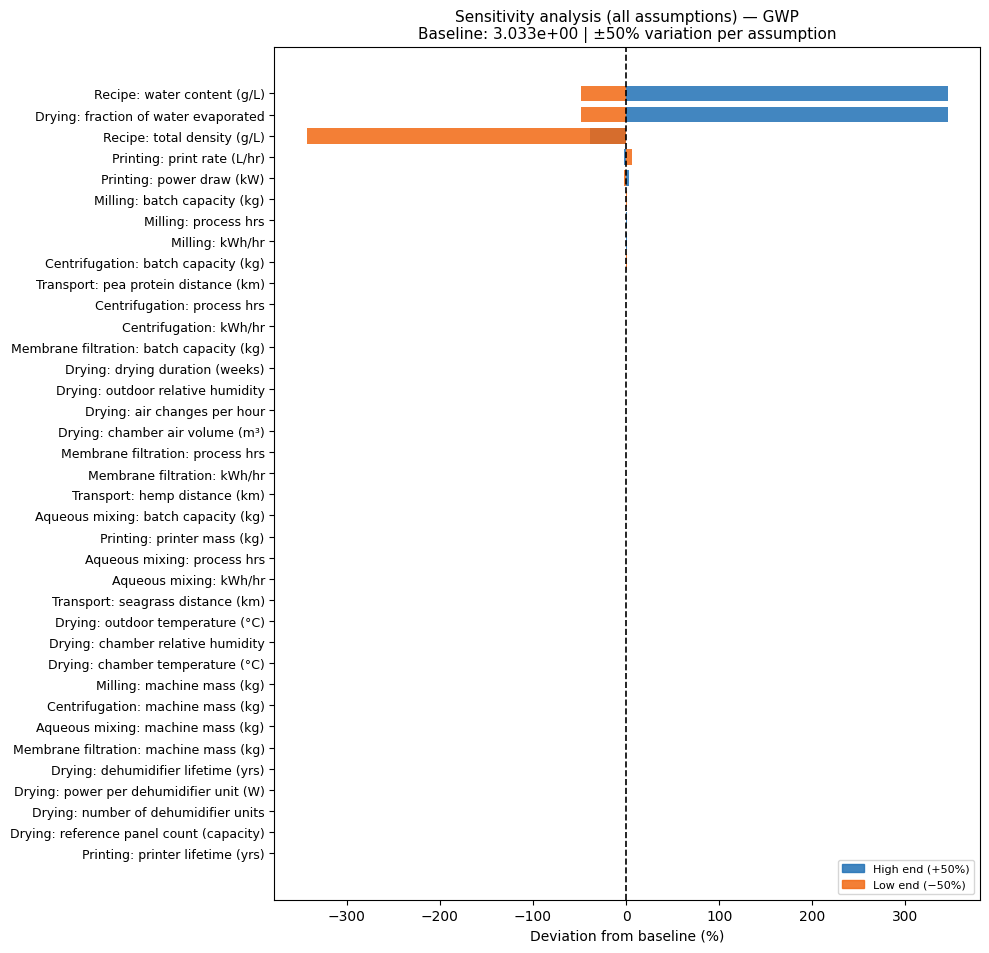

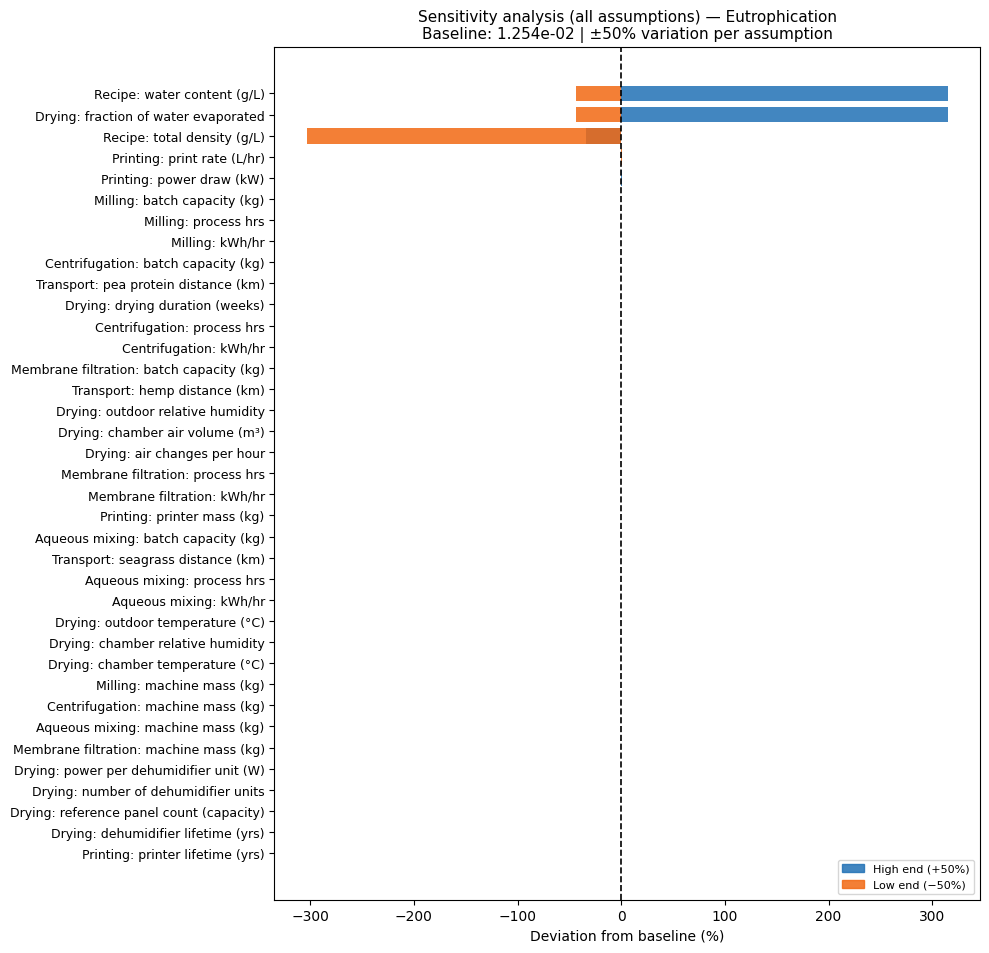

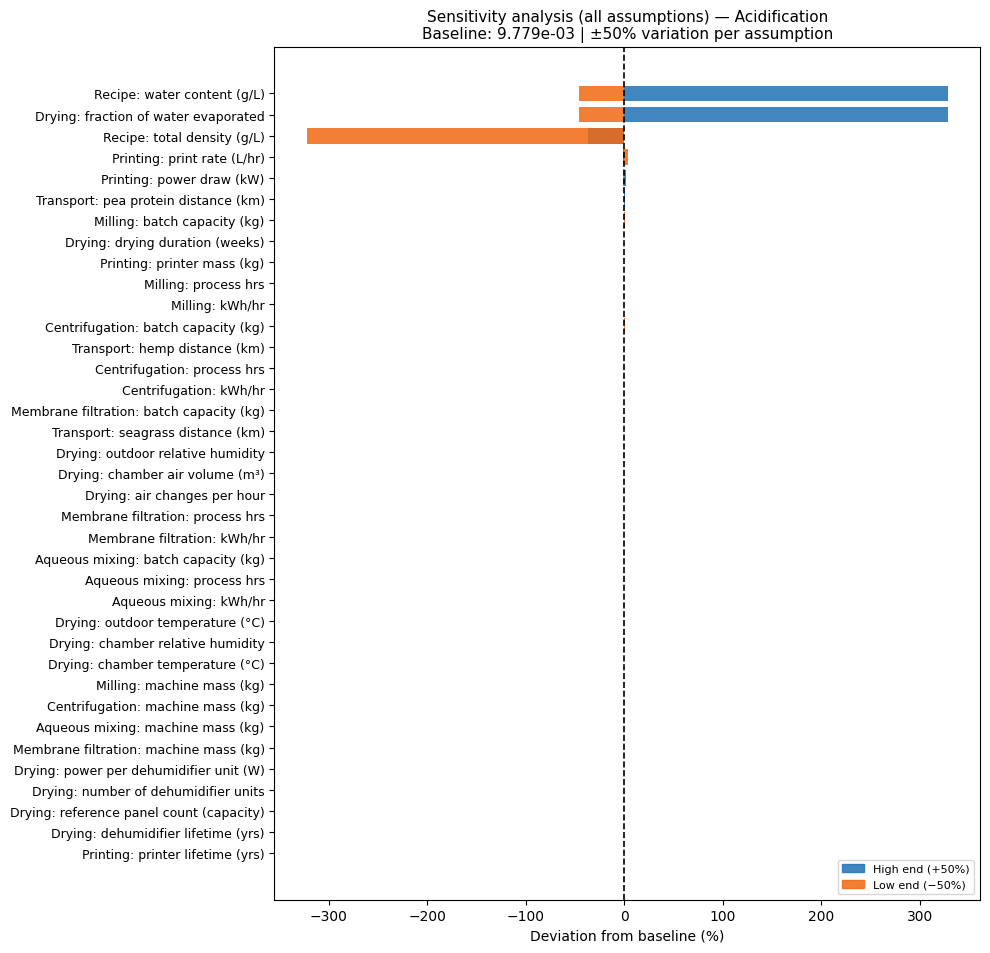

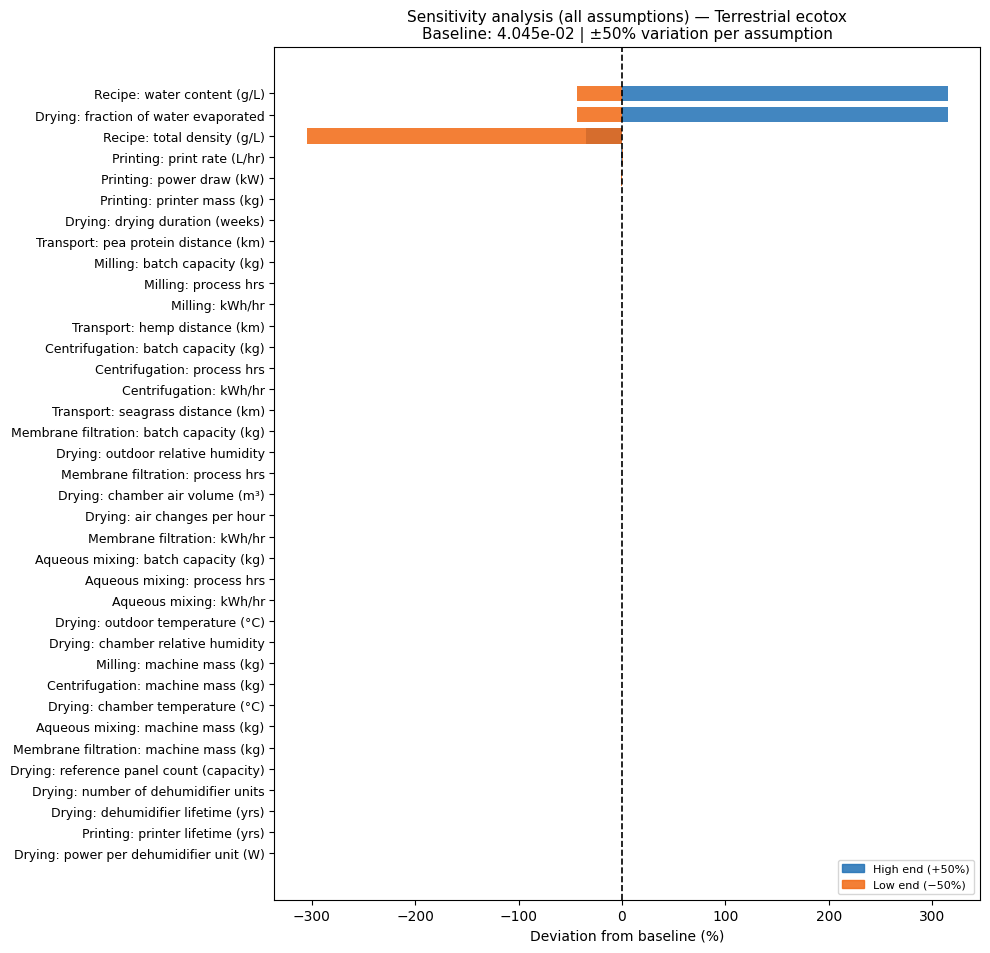

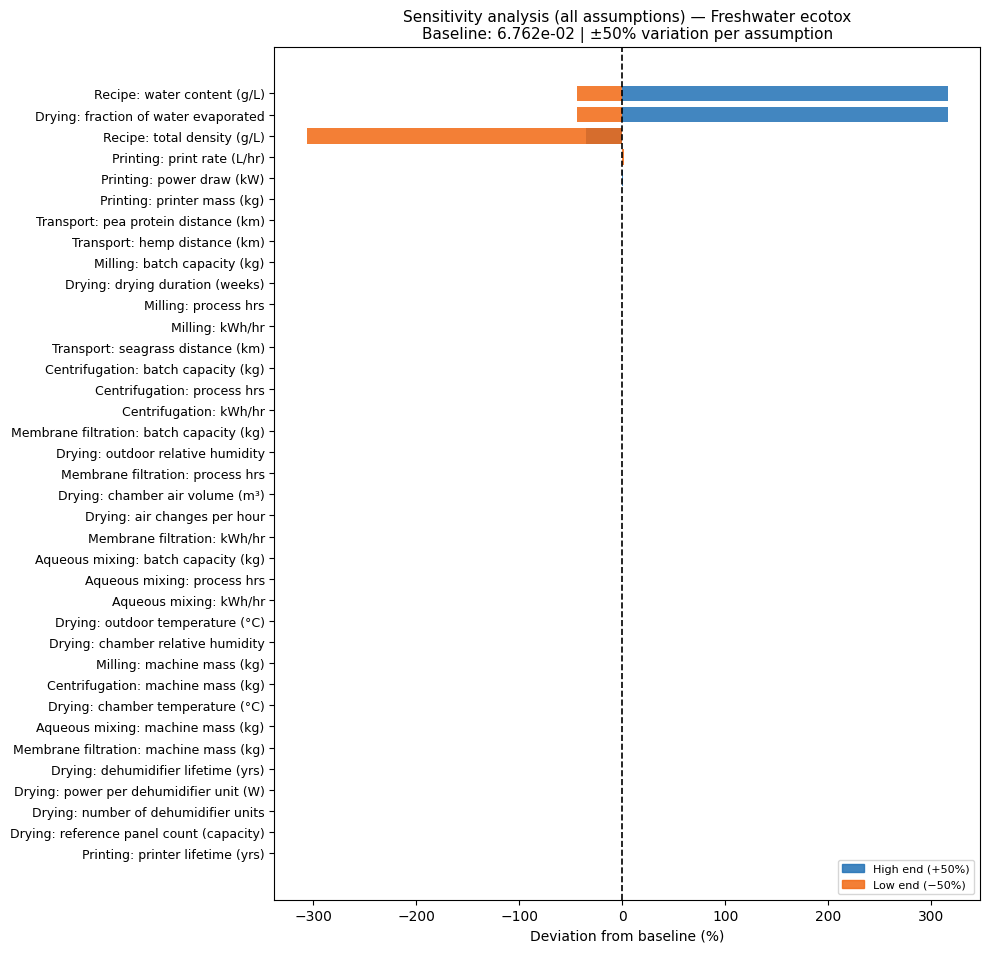

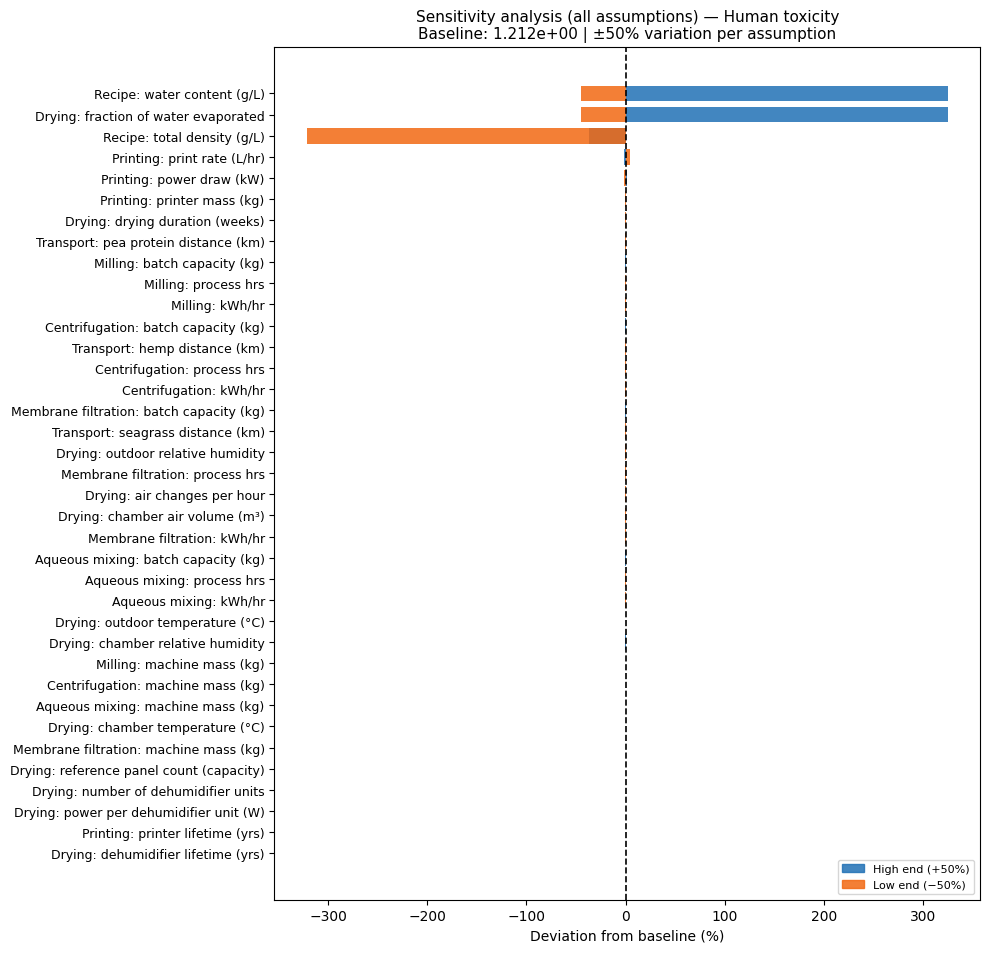

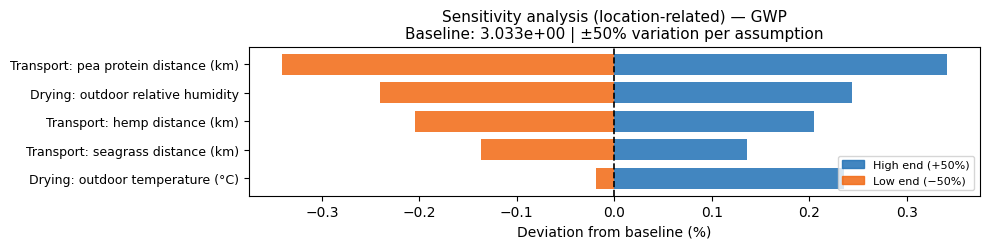

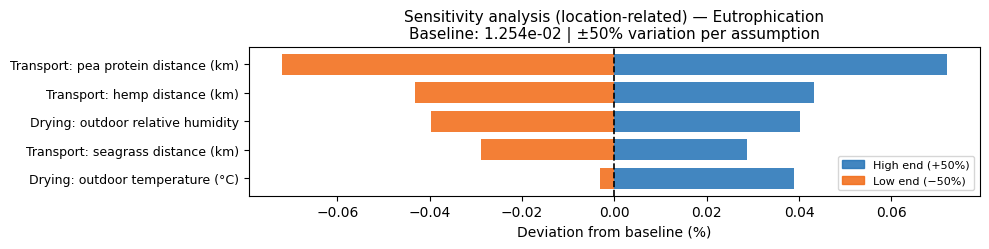

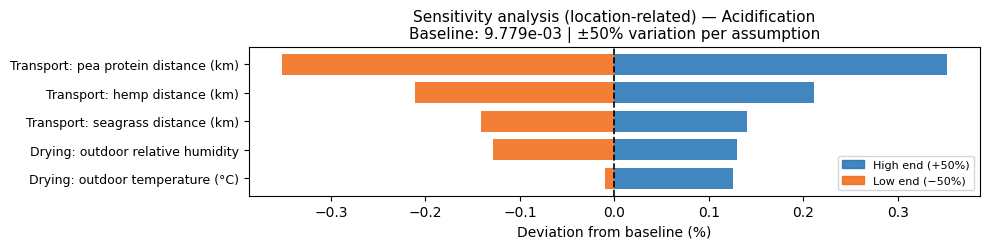

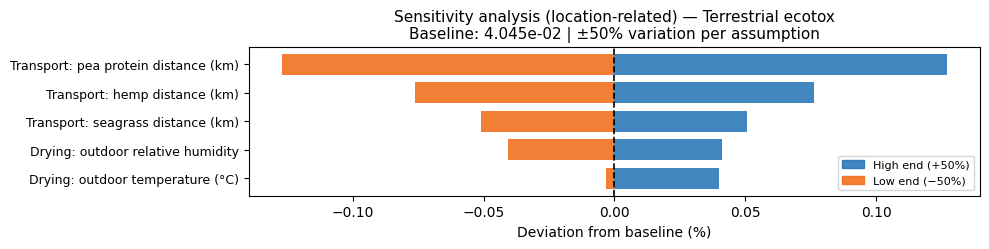

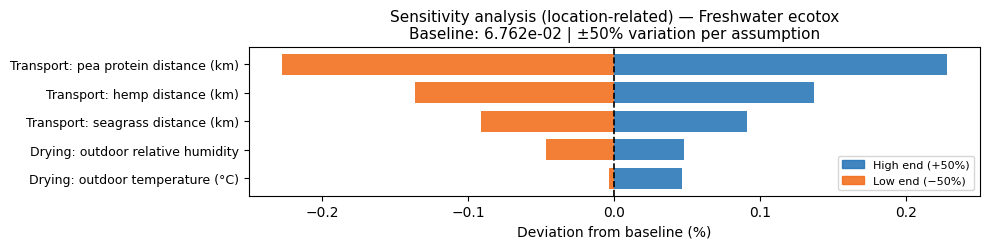

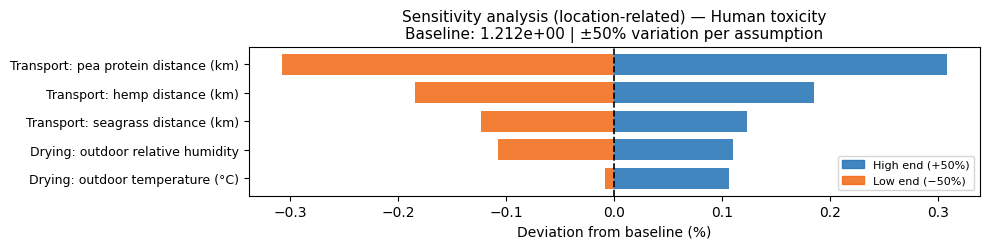

In [58]:
import matplotlib.patches as mpatches

def plot_tornado(method_results, baseline_scores, labels_dict, title_suffix, variation=VARIATION):
    """Plot a tornado chart for one set of sensitivity results."""
    for method_label, results in method_results.items():
        baseline_score = baseline_scores[method_label]

        rows = []
        for param_key, scores in results.items():
            swing = scores['high'] - scores['low']
            rows.append({
                'param':     param_key,
                'label':     labels_dict.get(param_key, param_key),
                'low':       scores['low'],
                'high':      scores['high'],
                'swing':     abs(swing),
                'direction': swing,
            })

        df_sa = pd.DataFrame(rows).sort_values('swing', ascending=True)

        fig, ax = plt.subplots(figsize=(10, len(df_sa) * 0.22 + 1.5))
        y_positions = np.arange(len(df_sa))

        for i, row in enumerate(df_sa.itertuples()):
            left  = (min(row.low, row.high) - baseline_score) / abs(baseline_score) * 100
            right = (max(row.low, row.high) - baseline_score) / abs(baseline_score) * 100
            color_right = '#2171b5' if row.direction >= 0 else '#f16913'
            color_left  = '#f16913' if row.direction >= 0 else '#2171b5'
            ax.barh(i, right, left=0, height=0.75, color=color_right, alpha=0.85)
            ax.barh(i, left,  left=0, height=0.75, color=color_left,  alpha=0.85)

        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        ax.set_yticks(y_positions)
        ax.set_yticklabels(df_sa['label'], fontsize=9)
        ax.set_xlabel('Deviation from baseline (%)', fontsize=10)
        ax.set_title(
            f'Sensitivity analysis ({title_suffix}) — {method_label}\n'
            f'Baseline: {baseline_score:.3e} | ±{int(variation*100)}% variation per assumption',
            fontsize=11
        )
        legend_handles = [
            mpatches.Patch(color='#2171b5', alpha=0.85, label=f'High end (+{int(variation*100)}%)'),
            mpatches.Patch(color='#f16913', alpha=0.85, label=f'Low end (−{int(variation*100)}%)'),
        ]
        ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
        plt.tight_layout()
        plt.show()

# Plot all base assumptions
plot_tornado(sensitivity_results, baseline_scores, ASSUMPTION_LABELS, 'all assumptions')

# Plot location-related assumptions only
plot_tornado(sensitivity_results_location, baseline_scores, ASSUMPTION_LABELS_locationRelated, 'location-related')

## Varying flow amounts

In [50]:
# ── Collect all foreground exchanges to vary ──────────────────────────────────
# We read every technosphere exchange from every node in your custom database,
# storing the node name, the input name, and the baseline amount.

db = bd.Database(DB_NAME)

FLOW_PARAMS = []  # list of dicts: {node_name, input_name, label, base_amount}

for node in db:
    for edge in node.technosphere():
        base_amount = edge['amount']
        if base_amount == 0:
            continue
        FLOW_PARAMS.append({
            'node_name':  node['name'],
            'input_name': edge.input['name'],
            'label':      f"{node['name']}  →  {edge.input['name']}",
            'base_amount': base_amount,
        })

print(f'Found {len(FLOW_PARAMS)} foreground exchanges to vary:')
for p in FLOW_PARAMS:
    print(f"  [{p['node_name']}]  {p['input_name']}  =  {p['base_amount']:.4g}")

Found 29 foreground exchanges to vary:
  [seagrass filler production]  flax straw production, dew-retted  =  1
  [seagrass filler production]  market for transport, freight, lorry, unspecified  =  0.1
  [Kiln baking - 150 degress for 2 hours]  3D printing  =  1.1
  [Kiln baking - 150 degress for 2 hours]  market for electricity, medium voltage  =  1.048
  [Kiln baking - 150 degress for 2 hours]  market for industrial furnace, natural gas  =  9.567e-07
  [membrane filtration]  centrifugation  =  1
  [membrane filtration]  market for electricity, medium voltage  =  0.018
  [membrane filtration]  market for industrial machine, heavy, unspecified  =  5.479e-06
  [centrifugation]  aqueous mixing  =  1
  [centrifugation]  market for electricity, medium voltage  =  0.028
  [centrifugation]  market for industrial machine, heavy, unspecified  =  1.461e-05
  [3D printing]  market for electricity, medium voltage  =  0.1176
  [3D printing]  industrial machine production, heavy, unspecified  =  0.0

In [51]:
def set_exchange_amount(node_name, input_name, amount):
    """Set a single exchange amount by node name and input name."""
    node = bd.get_node(name=node_name, database=DB_NAME)
    edge = [e for e in node.edges() if input_name in e.input['name']][0]
    edge['amount'] = amount
    edge.save()

In [52]:
VARIATION = 0.5   # ±50%

# ── Baseline ──────────────────────────────────────────────────────────────────
print('Computing baseline...')
baseline_scores = run_lca_multi()
for label, score in baseline_scores.items():
    print(f'  Baseline {label}: {score:.4e}')

# ── One-at-a-time sweep ───────────────────────────────────────────────────────
# flow_sensitivity[method_label][i] = {'low': score, 'high': score}
flow_sensitivity = {label: {} for label in METHODS}

for i, param in enumerate(FLOW_PARAMS):
    node_name  = param['node_name']
    input_name = param['input_name']
    base_val   = param['base_amount']
    low_val    = base_val * (1 - VARIATION)
    high_val   = base_val * (1 + VARIATION)

    for variant_label, test_val in [('low', low_val), ('high', high_val)]:
        set_exchange_amount(node_name, input_name, test_val)
        scores = run_lca_multi()
        for method_label, score in scores.items():
            flow_sensitivity[method_label].setdefault(i, {})[variant_label] = score

    # Restore this exchange before moving to the next
    set_exchange_amount(node_name, input_name, base_val)
    print(f'  [{i+1}/{len(FLOW_PARAMS)}] {node_name} → {input_name}')

print('\nDone.')

Computing baseline...
  Baseline GWP: 3.0333e+00
  Baseline Eutrophication: 1.2543e-02
  Baseline Acidification: 9.7788e-03
  Baseline Terrestrial ecotox: 4.0452e-02
  Baseline Freshwater ecotox: 6.7619e-02
  Baseline Human toxicity: 1.2117e+00
  [1/29] seagrass filler production → flax straw production, dew-retted
  [2/29] seagrass filler production → market for transport, freight, lorry, unspecified
  [3/29] Kiln baking - 150 degress for 2 hours → 3D printing
  [4/29] Kiln baking - 150 degress for 2 hours → market for electricity, medium voltage
  [5/29] Kiln baking - 150 degress for 2 hours → market for industrial furnace, natural gas
  [6/29] membrane filtration → centrifugation
  [7/29] membrane filtration → market for electricity, medium voltage
  [8/29] membrane filtration → market for industrial machine, heavy, unspecified
  [9/29] centrifugation → aqueous mixing
  [10/29] centrifugation → market for electricity, medium voltage
  [11/29] centrifugation → market for industrial m

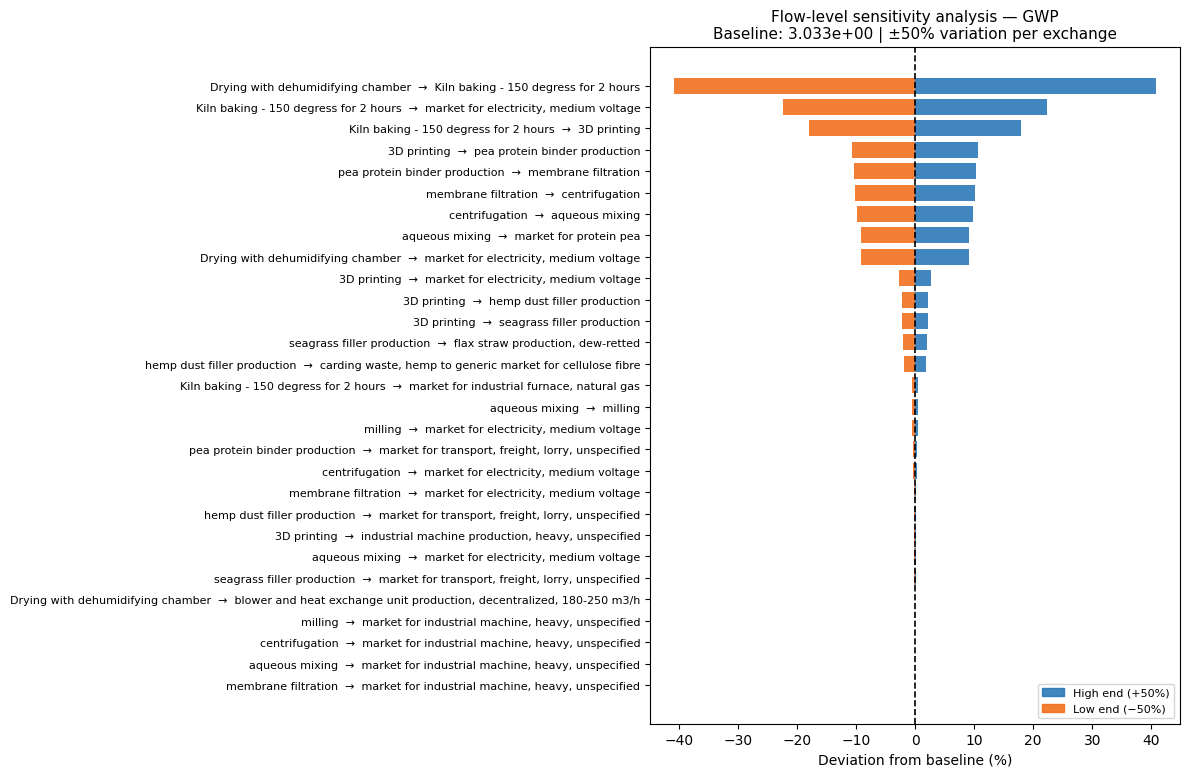

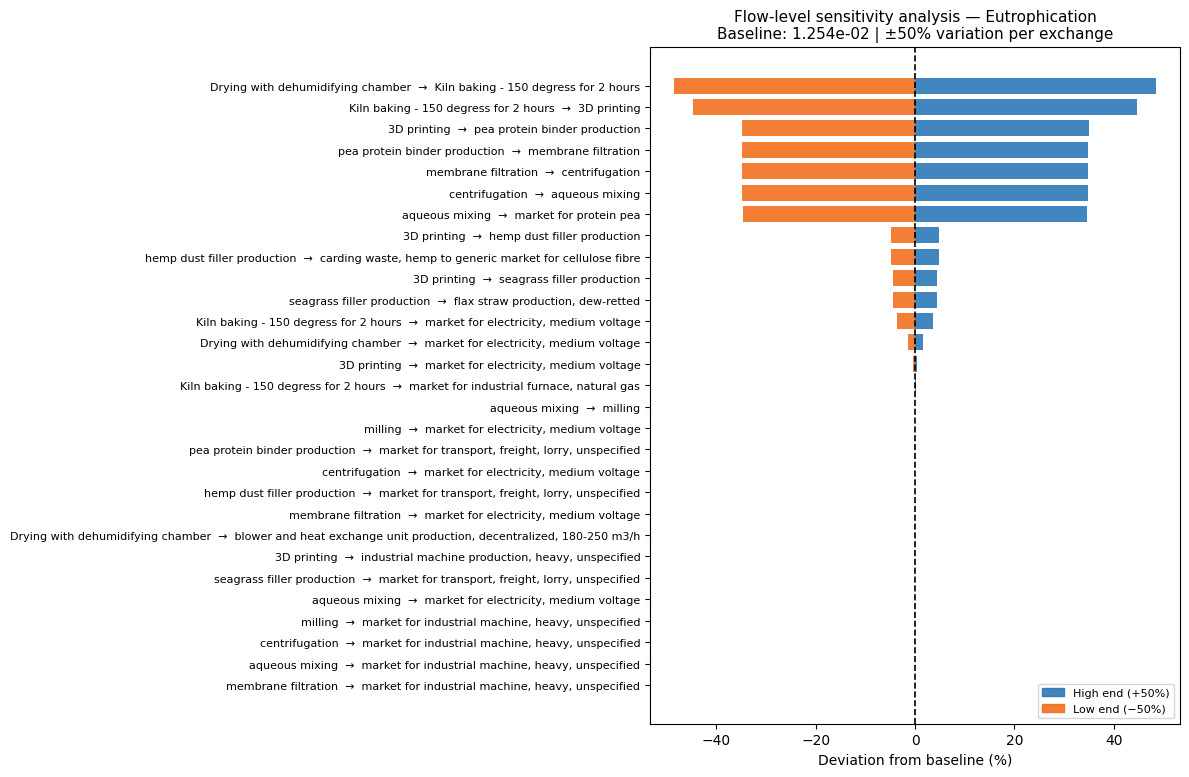

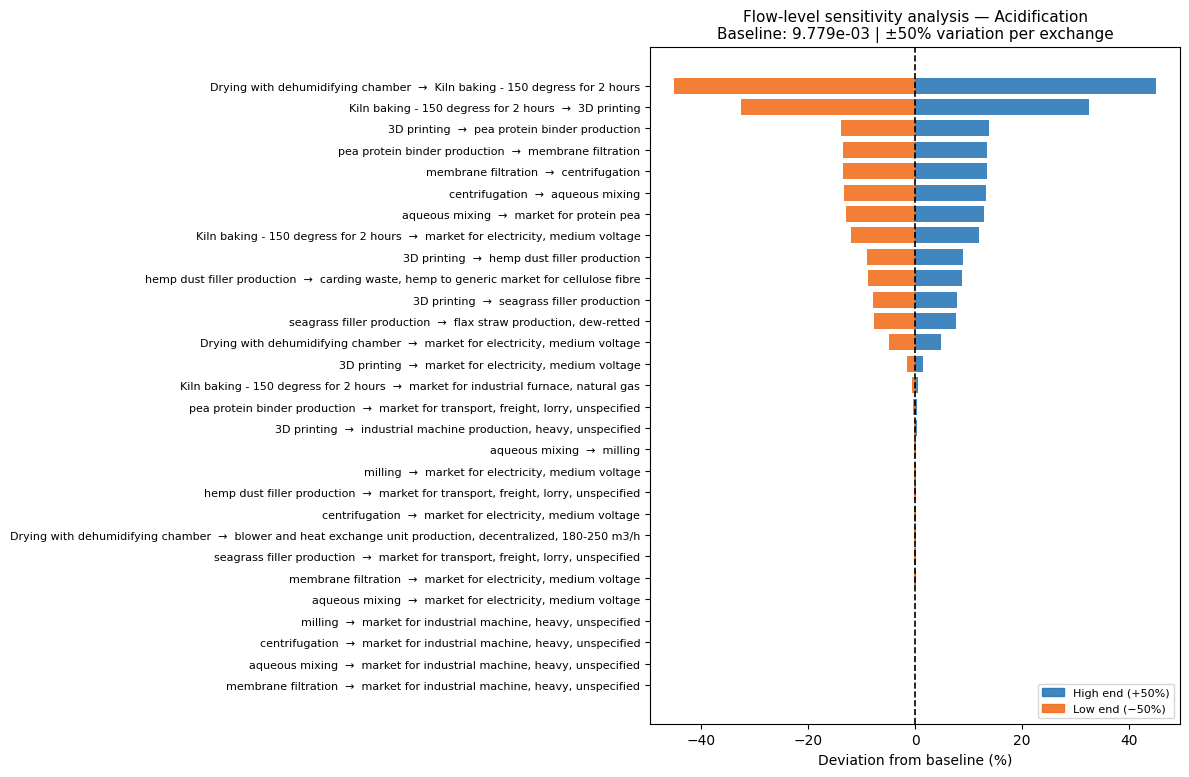

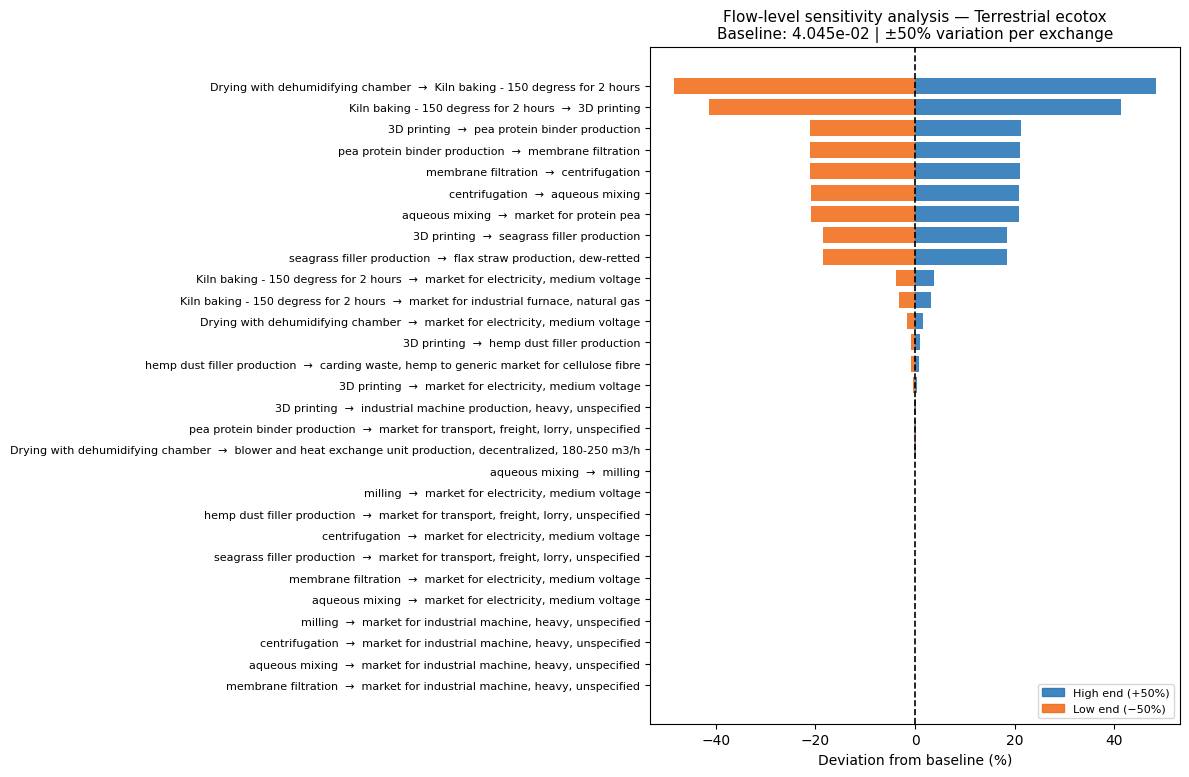

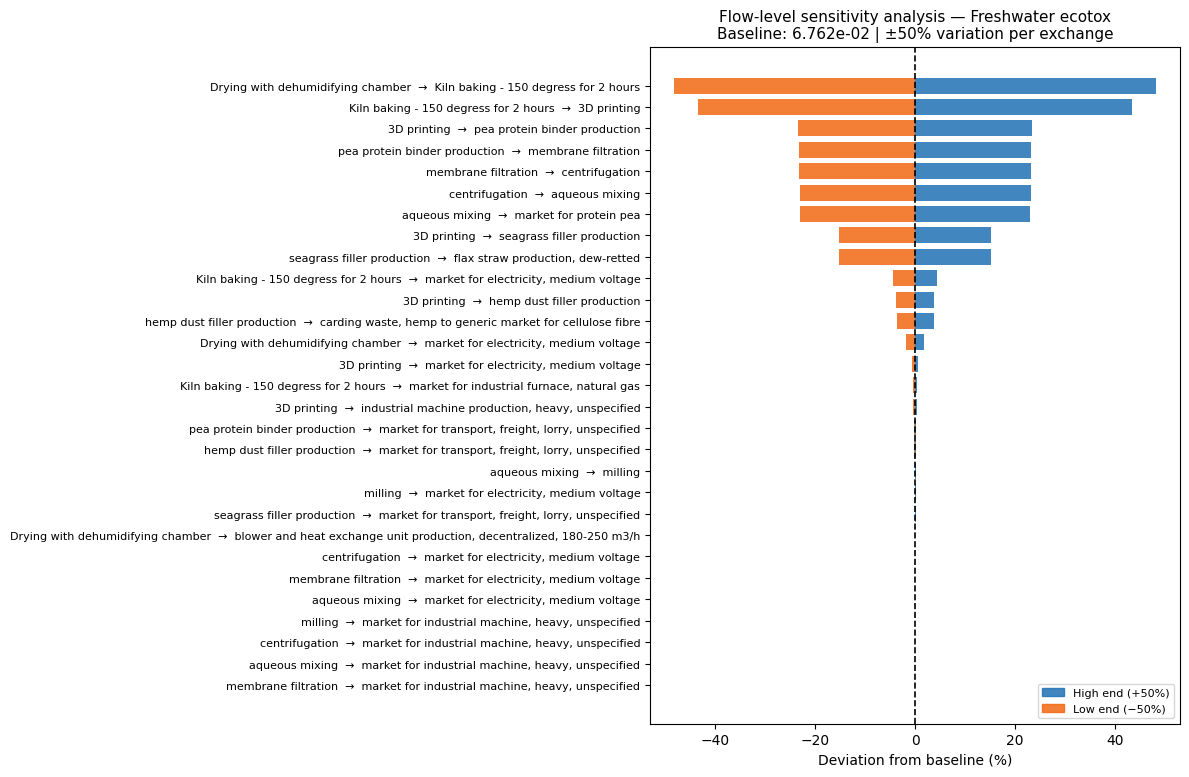

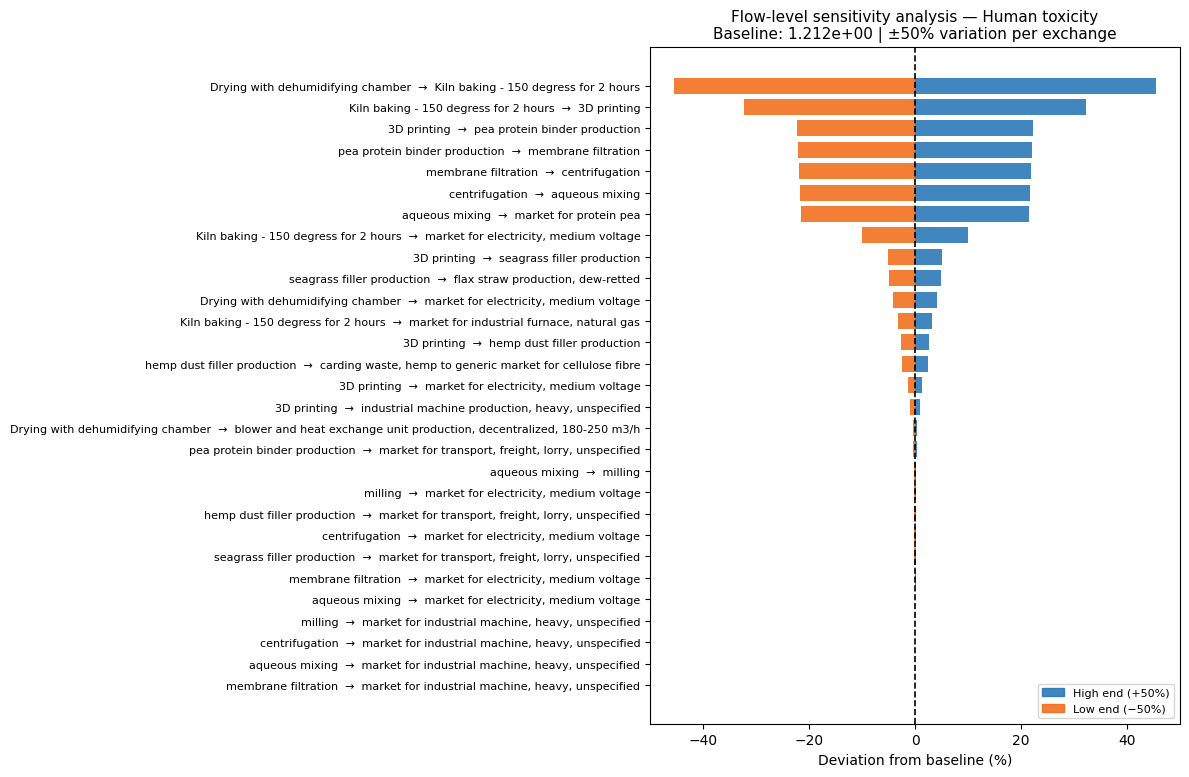

In [53]:
import matplotlib.patches as mpatches

for method_label, method_results in flow_sensitivity.items():
    baseline_score = baseline_scores[method_label]
    method_key = METHODS[method_label]

    # Build dataframe
    rows = []
    for i, scores in method_results.items():
        swing = scores['high'] - scores['low']
        rows.append({
            'label':     FLOW_PARAMS[i]['label'],
            'low':       scores['low'],
            'high':      scores['high'],
            'swing':     abs(swing),
            'direction': swing,
        })

    df_sa = pd.DataFrame(rows).sort_values('swing', ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(12, len(df_sa) * 0.22 + 1.5))
    bar_height = 0.75
    y_positions = np.arange(len(df_sa))

    for i, row in enumerate(df_sa.itertuples()):
        left  = (min(row.low, row.high) - baseline_score) / abs(baseline_score) * 100
        right = (max(row.low, row.high) - baseline_score) / abs(baseline_score) * 100
        color_right = '#2171b5' if row.direction >= 0 else '#f16913'
        color_left  = '#f16913' if row.direction >= 0 else '#2171b5'
        ax.barh(i, right, left=0, height=bar_height, color=color_right, alpha=0.85)
        ax.barh(i, left,  left=0, height=bar_height, color=color_left,  alpha=0.85)

    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(df_sa['label'], fontsize=8)
    ax.set_xlabel('Deviation from baseline (%)', fontsize=10)
    ax.set_title(
        f'Flow-level sensitivity analysis — {method_label}\n'
        f'Baseline: {baseline_score:.3e} | ±{int(VARIATION*100)}% variation per exchange',
        fontsize=11
    )

    legend_handles = [
        mpatches.Patch(color='#2171b5', alpha=0.85, label='High end (+50%)'),
        mpatches.Patch(color='#f16913', alpha=0.85, label='Low end (−50%)'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()